<a href="https://colab.research.google.com/github/annapetrbok/ee467wi2026/blob/main/homework_3_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EE P595 Homework 3: Identifying Malicious URLs (PyTorch)

<span style="color:red">**Released Date: February 5, 2026**</span>  
<span style="color:red">**Due Date: February 22, 2026**</span>

Build a 1D CNN to classify malicious HTTP request URLs using N-gram embeddings.

**Key Concepts:** N-gram extraction, Co-occurrence matrix, TruncatedSVD, 1D CNN

**Teammate:** _(Name if applicable)_

In [2]:
%pip install torch tqdm assertpy scikit-learn pandas matplotlib

  Preparing metadata (setup.py) ... done
  Created wheel for assertpy: filename=assertpy-1.1-py3-none-any.whl size=42897 sha256=aca63dd86c8ba5010c7e5f6ca2e23a4919050de5c7d1e5cfafd4f8c6436f0f9c
  Stored in directory: /root/.cache/pip/wheels/e9/a6/9e/a5cead15269b79ab7ebf051cfc3f7adcbd5a880e683e94736a
Successfully built assertpy


## 1. Data Loading

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import tarfile

# Extract the dataset if it's compressed
try:
    with tarfile.open('./waf-urls.tar.xz', 'r:xz') as tar:
        tar.extractall()
except FileNotFoundError:
    # If the tar.xz file is not found, assume it's already extracted or not present
    print("waf-urls.tar.xz not found, assuming waf-urls.csv is already available.")
except tarfile.ReadError:
    print("Could not read waf-urls.tar.xz, assuming waf-urls.csv is already available.")

# Load WAF URLs dataset
df = pd.read_csv('./waf-urls.csv')
print(f'Dataset: {len(df)} URLs')

# Split: 60% train, 20% val, 20% test
urls_tv, urls_test, labels_tv, labels_test = train_test_split(
    df['url'], df['label'], test_size=0.2, random_state=12345)
urls_train, urls_vali, labels_train, labels_vali = train_test_split(
    urls_tv, labels_tv, test_size=0.25, random_state=12345)

print(f'Train: {len(urls_train)}, Val: {len(urls_vali)}, Test: {len(urls_test)}')


/tmp/ipykernel_675/1486144823.py:9: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall()


Dataset: 60547 URLs
Train: 36327, Val: 12110, Test: 12110


## 2. N-Gram Functions

In [4]:
from assertpy import assert_that
from tqdm import tqdm

def iter_ngrams(text, n, start_symbol='\x00', end_symbol='\x01'):
    """Generate N-grams with start/end padding."""
    ## [ TODO 1 ] Implement N-gram generation
    # - Pad (n-1) start_symbols before text
    start_symbols = start_symbol * (n - 1)
    text = start_symbols + text
    # - Pad n end_symbols after text
    end_symbols = end_symbol * n
    text += end_symbols
    # - Return generator of N-grams
    return (text[i:i+n] for i in range(len(text) - n + 1))



# Test
assert_that(list(iter_ngrams('/test', n=3))).is_equal_to([
    '\x00\x00/', '\x00/t', '/te', 'tes', 'est', 'st\x01', 't\x01\x01', '\x01\x01\x01'
])

In [5]:
def build_ngram_mapping(urls, n, rare_threshold=2):
    """Build bidirectional N-gram to index mapping."""
    ngram_count = {}

    print('Counting N-grams...')
    for url in tqdm(urls):
        for ngram in iter_ngrams(url, n):
            ## [ TODO 2.1 ] Count N-gram occurrences
            if ngram in ngram_count:
                ngram_count[ngram] += 1
            else:
                ngram_count[ngram] = 1 # Initialize count for new ngram

    n2i, i2n = {}, []
    n_rare = 0

    print('Building mapping...')
    for ngram, count in tqdm(ngram_count.items()):
        ## [ TODO 2.2 ] Build mapping (only if count >= rare_threshold)
        # - Add to n2i and i2n if frequent
        if count >= rare_threshold:
            n2i[ngram] = len(i2n)
            i2n.append(ngram)
        # - Track n_rare for rare N-grams
        else:
          n_rare += 1

    print(f'Unique: {len(ngram_count)}, Kept: {len(i2n)}')
    return n2i, i2n

# Test
n2i_test, i2n_test = build_ngram_mapping(['/x', '/xyz/23', '/233'], n=3)
assert_that(len(n2i_test)).is_equal_to(5)

Counting N-grams...


100%|██████████| 3/3 [00:00<00:00, 16320.25it/s]


Building mapping...


100%|██████████| 15/15 [00:00<00:00, 105384.52it/s]

Unique: 15, Kept: 5


## 3. Co-occurrence Matrix

In [6]:
from scipy.sparse import dok_matrix

def build_cooccurrence_matrix(urls, n, n2i_mapping, window_size):
    """Build normalized co-occurrence matrix."""
    n_ngram = len(n2i_mapping)
    unknown_idx = n_ngram
    co_matrix = dok_matrix((n_ngram+1, n_ngram+1))

    print(f'Building co-occurrence...')
    for url in tqdm(urls):
        prev_indices = []
        for ngram in iter_ngrams(url, n):
            ## [ TODO 3.1 ] Get N-gram index (unknown_idx if not found)
            idx = n2i_mapping.get(ngram, unknown_idx)

            ## [ TODO 3.2 ] Update co-occurrence for prev neighbors in window
            for prev_idx in prev_indices[-window_size:]:
                co_matrix[prev_idx, idx] += 1

            prev_indices.append(idx)

    print('Normalizing...')
    row_sums = co_matrix.sum(axis=1)
    ## [ TODO 3.3 ] Normalize rows to probability distributions
    for (i, j) in tqdm(list(co_matrix.keys())):
        co_matrix[i, j] /= row_sums[i]

    return co_matrix

In [7]:
# Build N-gram mapping and co-occurrence matrix
N = 4
WINDOW_SIZE = 5

n2i_urls, i2n_urls = build_ngram_mapping(urls_train, N)
cooccurrence_urls = build_cooccurrence_matrix(urls_train, N, n2i_urls, WINDOW_SIZE)
print(f'Co-occurrence shape: {cooccurrence_urls.shape}')

Counting N-grams...


100%|██████████| 36327/36327 [00:01<00:00, 31633.55it/s]


Building mapping...


100%|██████████| 160195/160195 [00:00<00:00, 2072992.22it/s]


Unique: 160195, Kept: 82844
Building co-occurrence...


100%|██████████| 36327/36327 [04:32<00:00, 133.27it/s]


Normalizing...


100%|██████████| 1317180/1317180 [00:39<00:00, 33682.02it/s]

Co-occurrence shape: (82845, 82845)


## 4. Embedding via TruncatedSVD

In [8]:
from sklearn.decomposition import TruncatedSVD

EMBEDDING_DIMS = 10

## [ TODO 4 ] Create TruncatedSVD and fit_transform co-occurrence matrix
# svd = TruncatedSVD(n_components=EMBEDDING_DIMS, n_iter=20, random_state=42)
# embedding_svd = svd.fit_transform(cooccurrence_urls)
svd = TruncatedSVD(n_components=EMBEDDING_DIMS, n_iter=20, random_state=42)
embedding_svd = svd.fit_transform(cooccurrence_urls)

assert embedding_svd.shape == (len(n2i_urls)+1, EMBEDDING_DIMS)

## 5. PyTorch Model

In [9]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


In [10]:
def transform_urls(urls, padded_len, n, n2i_mapping, pad_symbol='\x01'):
    """Convert URLs to N-gram index sequences."""
    batch = np.empty((len(urls), padded_len + n), dtype=int)
    unknown_idx = len(n2i_mapping)

    for i, url in enumerate(urls):
        ## [ TODO 5.1 ] Pad URL to padded_len
        url = url + pad_symbol * (padded_len - len(url))

        ## [ TODO 5.2 ] Convert N-grams to indices
        for j, ngram in enumerate(iter_ngrams(url, n)):
            batch[i, j] = n2i_mapping.get(ngram, unknown_idx)

    return batch

In [11]:
class URLDataset(Dataset):
    def __init__(self, urls, labels, padded_len, n, n2i_mapping):
        self.data = transform_urls(list(urls), padded_len, n, n2i_mapping)
        self.labels = labels.values.astype(np.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return torch.tensor(self.data[idx], dtype=torch.long), torch.tensor(self.labels[idx])

In [18]:
import torch
import torch.nn as nn
from torch.nn import MaxPool1d, Linear, Conv1d, Sequential, ReLU, Dropout
from torch.utils.data import Dataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')


class URLCNN(nn.Module):
    """1D CNN for URL classification."""
    def __init__(self, n_ngram, embedding_weights, dropout=0.25):
        super().__init__()
        embed_dim = embedding_weights.shape[1]

        ## [ TODO 6.1 ] Embedding layer (frozen, initialized with embedding_weights)
        self.embedding = nn.Embedding.from_pretrained(torch.tensor(embedding_weights, dtype=torch.float32), freeze=True)

        ## [ TODO 6.2 ] Conv blocks
        # conv1: embed_dim -> 20, kernel=5, padding=2
        self.conv1 = nn.Sequential(
            nn.Conv1d(in_channels=embed_dim, out_channels=20, kernel_size=5, padding=2),
            nn.ReLU()
        )
        # conv2: 20 -> 40, kernel=5, padding=2
        self.conv2 = nn.Sequential(
            nn.Conv1d(in_channels=20, out_channels=40, kernel_size=5, padding=2),
            nn.ReLU()
        )
        # conv3: 40 -> 80, kernel=5, padding=2
        self.conv3 = nn.Sequential(
            nn.Conv1d(in_channels=40, out_channels=80, kernel_size=5, padding=2),
            nn.ReLU()
        )
        # pool1: MaxPool1d(2), pool2: MaxPool1d(5), pool3: MaxPool1d(5)
        self.pool1 = nn.MaxPool1d(kernel_size=2)
        self.pool2 = nn.MaxPool1d(kernel_size=5)
        self.pool3 = nn.MaxPool1d(kernel_size=5)

        # Calculate input features for the first FC layer
        # Based on MAX_URL_LEN=96, N=4, embed_dim=EMBEDDING_DIMS=10
        # Input sequence length to Conv1d after embedding and permute: MAX_URL_LEN + N = 96 + 4 = 100
        # Conv1d output length: (100 + 2*2 - 1*(5-1) - 1)/1 + 1 = 100
        # Pool1 output length: (100 - 2)/2 + 1 = 50
        # Conv2 output length: (50 + 2*2 - 1*(5-1) - 1)/1 + 1 = 50
        # Pool2 output length: (50 - 5)/5 + 1 = 10
        # Conv3 output length: (10 + 2*2 - 1*(5-1) - 1)/1 + 1 = 10
        # Pool3 output length: (10 - 5)/5 + 1 = 2
        # Flattened size: final_channels * final_length = 80 * 2 = 160
        fc_input_features = 160

        ## [ TODO 6.3 ] FC layers
        # fc1: 160 -> 16, fc2: 16 -> 1
        self.dropout = nn.Dropout(p=dropout)
        self.fc1 = nn.Linear(in_features=fc_input_features, out_features=16)
        self.fc2 = nn.Linear(in_features=16, out_features=1)

    def forward(self, x):
        ## [ TODO 6.4 ] Forward pass
        # Embedding -> permute -> conv blocks -> flatten -> FC -> sigmoid
        x = self.embedding(x)
        x = x.permute(0, 2, 1) # Change to (batch_size, embed_dim, seq_len) for Conv1d
        x = self.conv1(x)
        x = self.pool1(x)
        x = self.conv2(x)
        x = self.pool2(x)
        x = self.conv3(x)
        x = self.pool3(x)
        x = x.view(x.size(0), -1) # Flatten
        x = self.dropout(x)
        x = self.fc1(x)
        x = self.fc2(x)
        x = torch.sigmoid(x)
        return x


Device: cpu


In [19]:
# Hyperparameters
BATCH_SIZE = 256
MAX_URL_LEN = 96
N_EPOCHS = 10

# Create datasets
train_dataset = URLDataset(urls_train, labels_train, MAX_URL_LEN, N, n2i_urls)
val_dataset = URLDataset(urls_vali, labels_vali, MAX_URL_LEN, N, n2i_urls)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

model = URLCNN(len(n2i_urls), embedding_svd).to(device)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters())

In [22]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        ## [ TODO 7 ] Training step
        # optimizer.zero_grad(), forward, loss, backward, step
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y.unsqueeze(1))
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y)
        correct += ((out > 0.5) == y.unsqueeze(1)).sum().item()
        total += len(y)
    return total_loss / total, correct / total

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            total_loss += criterion(out, y.unsqueeze(1)).item() * len(y)
            correct += ((out > 0.5) == y.unsqueeze(1)).sum().item()
            total += len(y)
    return total_loss / total, correct / total

In [23]:
# Training loop
history = {'loss': [], 'acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(N_EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = evaluate(model, val_loader, criterion)
    history['loss'].append(train_loss)
    history['acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    print(f'Epoch {epoch+1}: Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}')

torch.save(model.state_dict(), './model-url-cnn.pt')

Epoch 1: Train Acc=0.7572, Val Acc=0.8832
Epoch 2: Train Acc=0.8896, Val Acc=0.9119
Epoch 3: Train Acc=0.9102, Val Acc=0.9206
Epoch 4: Train Acc=0.9246, Val Acc=0.9367
Epoch 5: Train Acc=0.9340, Val Acc=0.9429
Epoch 6: Train Acc=0.9411, Val Acc=0.9481
Epoch 7: Train Acc=0.9445, Val Acc=0.9496
Epoch 8: Train Acc=0.9485, Val Acc=0.9512
Epoch 9: Train Acc=0.9482, Val Acc=0.9457
Epoch 10: Train Acc=0.9506, Val Acc=0.9534


## 6. Evaluation

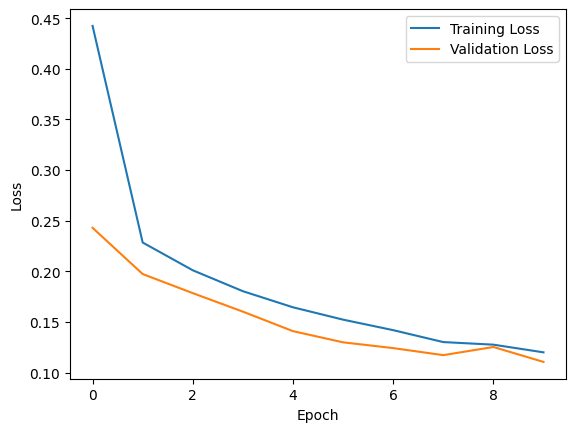

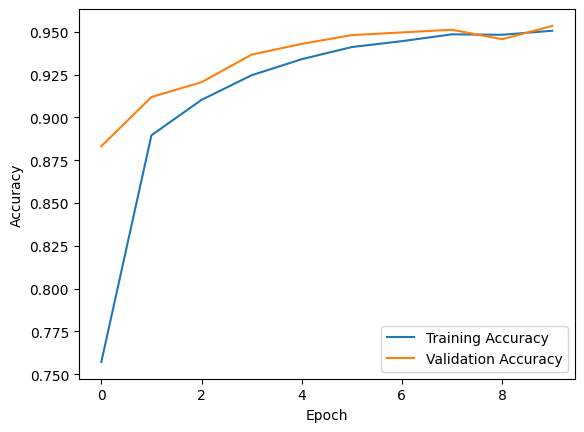

In [24]:
import matplotlib.pyplot as plt

## [ TODO 8 ] Plot loss and accuracy curves
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.plot(history['acc'], label='Training Accuracy')
plt.plot(history['val_acc'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [26]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

## [ TODO 9 ] Test evaluation
# - Create test dataset and loader
test_dataset = URLDataset(urls_test, labels_test, MAX_URL_LEN, N, n2i_urls)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

# - Predict and collect results
all_preds_probs = []
all_true_labels = []
with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        out = model(x)
        all_preds_probs.append(out.cpu().numpy())
        all_true_labels.append(y.cpu().numpy())

y_pred_probs = np.concatenate(all_preds_probs).flatten()
y_true = np.concatenate(all_true_labels).flatten()

# Convert probabilities to binary predictions and ensure true labels are int
y_pred = (y_pred_probs > 0.5).astype(int)
y_true = y_true.astype(int)

# - Print confusion matrix and classification report
print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))
print("\nClassification Report:")
print(classification_report(y_true, y_pred))


Confusion Matrix:
[[6716  427]
 [ 218 4749]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.94      0.95      7143
           1       0.92      0.96      0.94      4967

    accuracy                           0.95     12110
   macro avg       0.94      0.95      0.95     12110
weighted avg       0.95      0.95      0.95     12110



## Questions

**Q1: Analyze model performance. Does lower loss indicate higher accuracy?** (2 pts)

**Your Answer:** When looking at training and validation, can see that as loss goes down the accuracy increases. Makes sense since lower loss shows that models predictions are close to the correct classifications which by definition leads to higher accuracy. An example of this can be seen in training when epoch 1 has loss of 0.44 whereas epoch 10 has loss of 0.12. However the accuracy increased from 0.75 to 0.95.



**Q2: Is large window_size (e.g., 50) good? Other compression methods?** (2 pts)

**Your Answer:** Large window size is not good generally. Doesnt focus on strong local relationships and can have noise (look into irrelevant context). To generate compressed outcomes for N grams could also use an autoencoder by inputting the encoded N gram and bottleneck layer would compress it.



## Submission
Submit: `homework-3-student-20260205.ipynb` + `model-url-cnn.pt`